Cargadas 65 galaxias desde type/cls33.txt
Cargando masas desde el catálogo de grupos...
Extrayendo mergers desde los árboles SubLink...
Datos cargados. Generando figuras...
Las figuras se guardarán en: figuras_sn33/


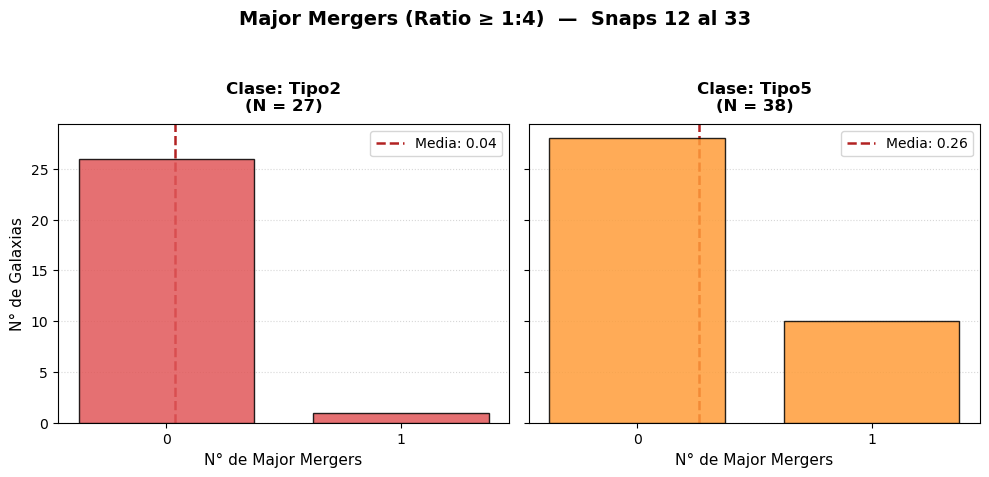

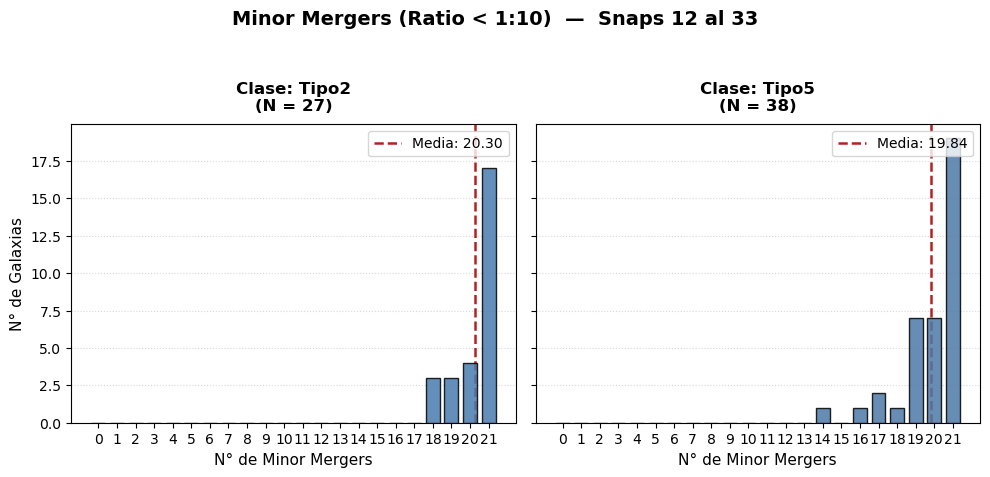

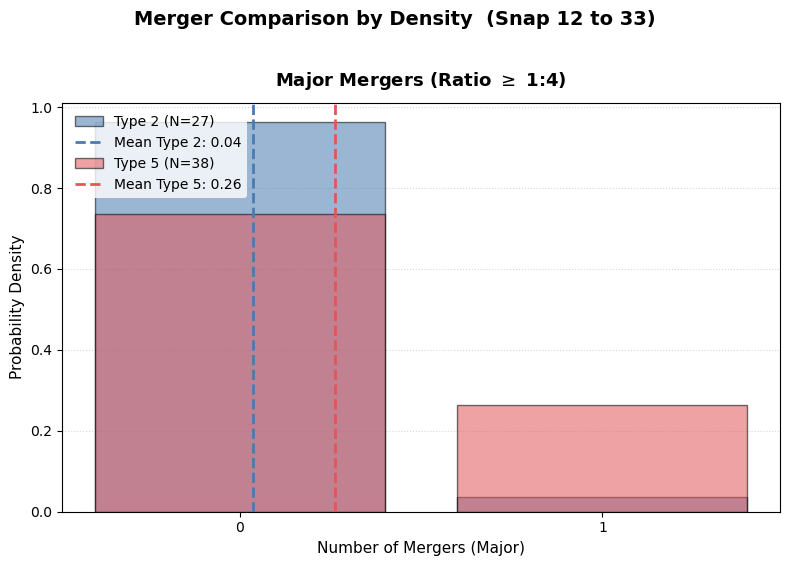

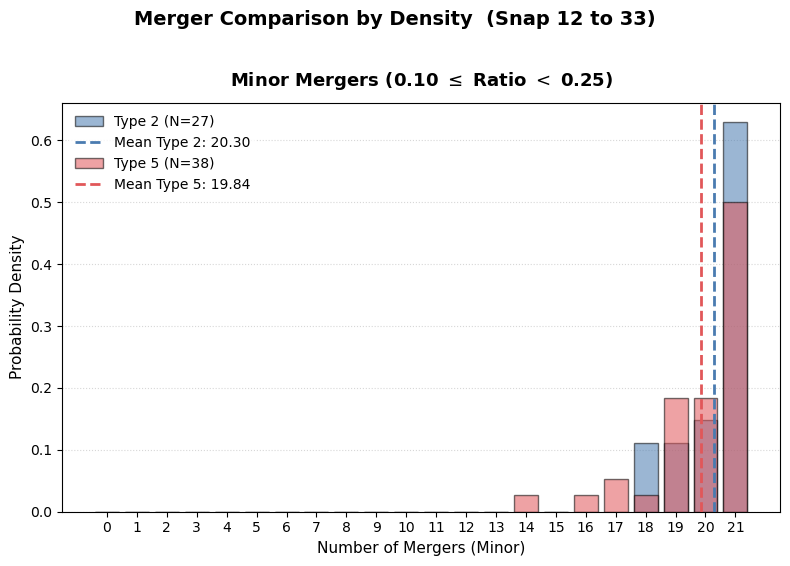

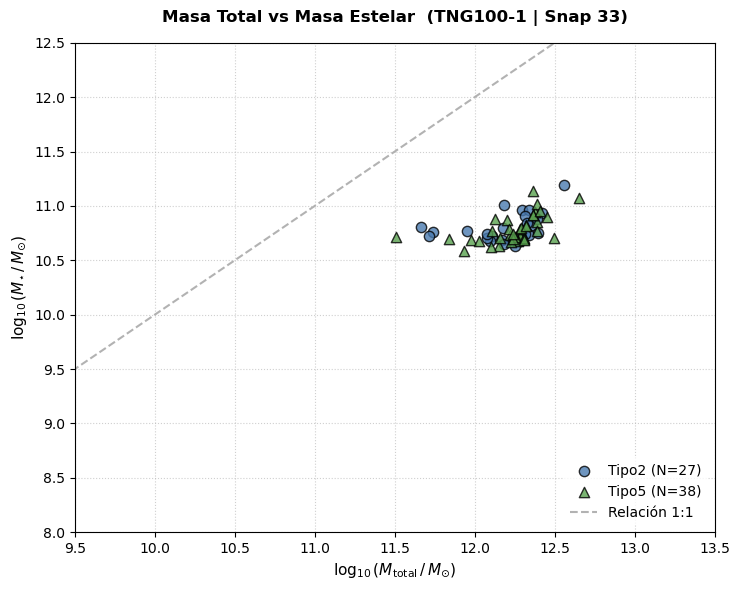

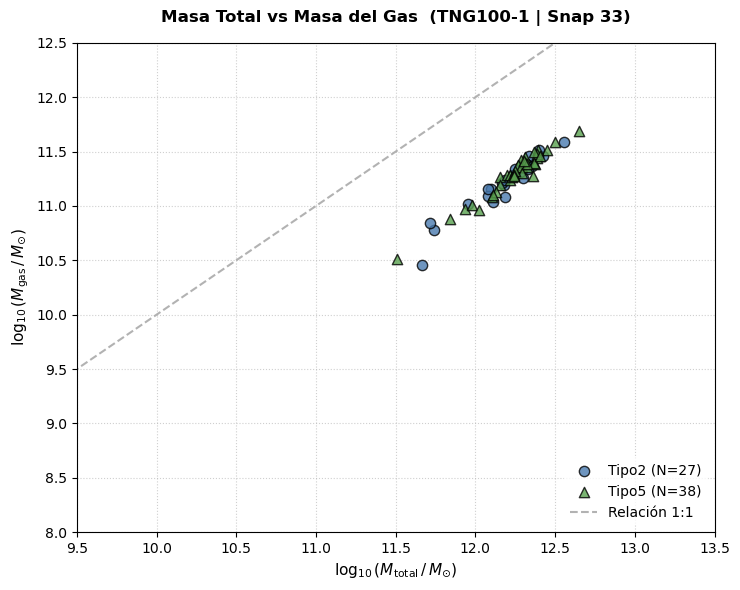

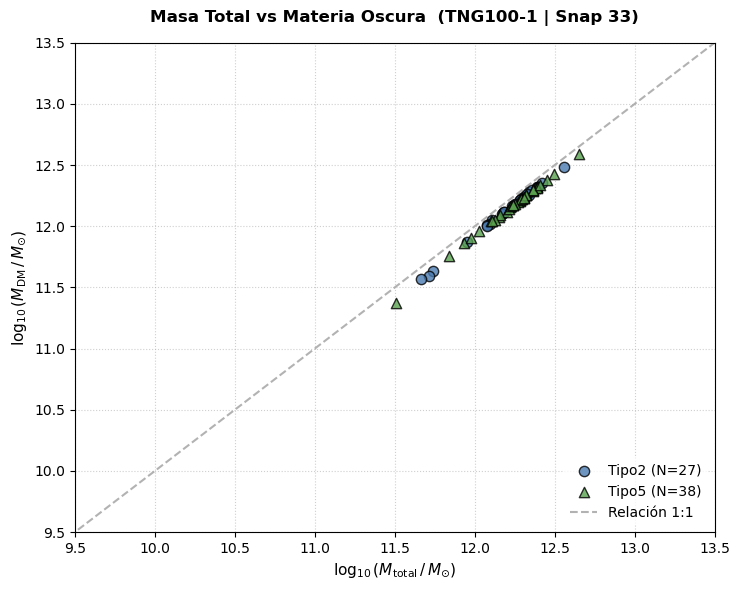

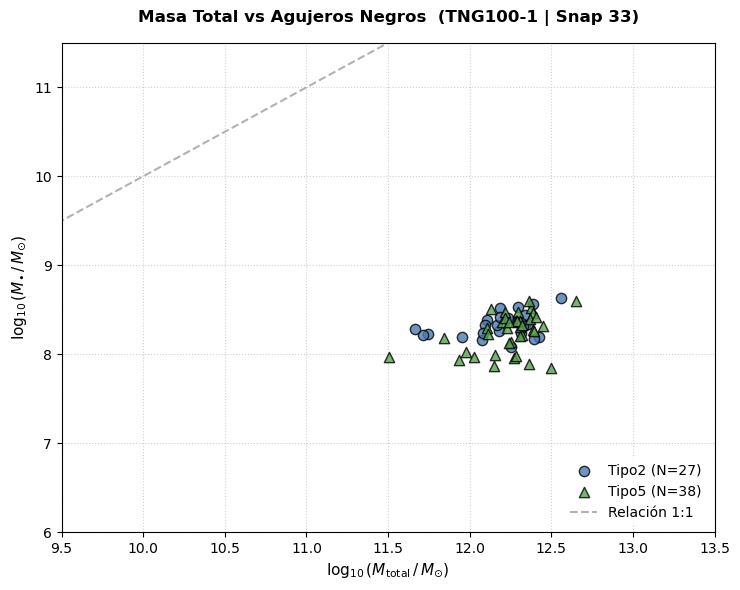

Todas las figuras generadas y guardadas correctamente.


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

# ============================================================
# CONFIGURACIÓN GLOBAL — EDITAR AQUÍ SEGÚN EL SNAPSHOT
# ============================================================
basePath          = '/home/tnguser/sims.TNG/TNG100-1/output/'
archivo_tipos     = "type/cls33.txt"
snapshot_presente = 33

SNAP_LIMITES = {99: 71, 85: 66, 67: 50, 50: 35, 33: 12}
snap_limite  = SNAP_LIMITES[snapshot_presente]

TIPOS_COMPARAR = ['Tipo2', 'Tipo5']   # Para los histogramas superpuestos de densidad

COLORES  = {'Tipo2': '#4A7BB0', 'Tipo3': '#E15759', 'Tipo5': '#59A14F'}
MARKERS  = {'Tipo2': 'o',       'Tipo3': 's',        'Tipo5': '^'}


# ============================================================
# 1. CARGA DE GALAXIAS
# ============================================================
if not os.path.exists(archivo_tipos):
    raise FileNotFoundError(f"No se encontró el archivo de tipos: {archivo_tipos}")

subhalo_ids    = []
tipos_galaxias = []

with open(archivo_tipos) as f:
    for line in f:
        partes = line.strip().split()
        if len(partes) == 2:
            try:
                tipos_galaxias.append(partes[0])
                subhalo_ids.append(int(partes[1]))
            except ValueError:
                continue

print(f"Cargadas {len(subhalo_ids)} galaxias desde {archivo_tipos}")
tipos_unicos = sorted(set(tipos_galaxias))
label_map    = {t: t.replace('Tipo', 'Type ') for t in tipos_unicos}


# ============================================================
# 2. CARGA DE MASAS DESDE LA SIMULACIÓN
# ============================================================
header = il.groupcat.loadHeader(basePath, snapshot_presente)
h      = header['HubbleParam']

masas = {t: {'total': [], 'estelar': [], 'gas': [], 'dm': [], 'bh': []}
         for t in tipos_unicos}

print("Cargando masas desde el catálogo de grupos...")
for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    try:
        sub    = il.groupcat.loadSingle(basePath, snapshot_presente, subhaloID=sid)
        m_tot  = sub['SubhaloMass']         * 1e10 / h   # Masa total
        m_gas  = sub['SubhaloMassType'][0]  * 1e10 / h   # Gas
        m_dm   = sub['SubhaloMassType'][1]  * 1e10 / h   # Materia oscura
        m_star = sub['SubhaloMassType'][4]  * 1e10 / h   # Estrellas
        m_bh   = sub['SubhaloMassType'][5]  * 1e10 / h   # Agujeros negros

        if m_tot > 0:
            masas[tipo]['total'].append(np.log10(m_tot))
            masas[tipo]['estelar'].append(np.log10(m_star) if m_star > 0 else 0)
            masas[tipo]['gas'].append(   np.log10(m_gas)   if m_gas  > 0 else 0)
            masas[tipo]['dm'].append(    np.log10(m_dm)    if m_dm   > 0 else 0)
            masas[tipo]['bh'].append(    np.log10(m_bh)    if m_bh   > 0 else 0)
    except Exception:
        continue


# ============================================================
# 3. EXTRACCIÓN DE MERGERS DESDE ÁRBOLES SUBLINK
# ============================================================
fields  = ['SnapNum', 'SubhaloMass', 'NextProgenitorID', 'FirstProgenitorID', 'SubhaloID']
mergers = {t: {'major': [], 'minor': []} for t in tipos_unicos}

print("Extrayendo mergers desde los árboles SubLink...")
for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    major_count = minor_count = 0

    tree = il.sublink.loadTree(basePath, snapshot_presente, sid, fields=fields, onlyMPB=False)

    if tree is None:
        mergers[tipo]['major'].append(0)
        mergers[tipo]['minor'].append(0)
        continue

    id_to_idx = {sub_id: idx for idx, sub_id in enumerate(tree['SubhaloID'])}
    curr_idx  = 0

    while curr_idx != -1:
        if tree['SnapNum'][curr_idx] < snap_limite:
            break

        next_prog_id = tree['NextProgenitorID'][curr_idx]
        if next_prog_id != -1:
            next_idx = id_to_idx.get(next_prog_id, -1)
            if next_idx != -1:
                m1 = tree['SubhaloMass'][curr_idx]
                m2 = tree['SubhaloMass'][next_idx]
                if m1 > 0 and m2 > 0:
                    ratio = min(m1, m2) / max(m1, m2)
                    if ratio >= 0.25:
                        major_count += 1
                    elif ratio < 0.10:
                        minor_count += 1

        first_prog_id = tree['FirstProgenitorID'][curr_idx]
        curr_idx      = id_to_idx.get(first_prog_id, -1)

    mergers[tipo]['major'].append(major_count)
    mergers[tipo]['minor'].append(minor_count)

print("Datos cargados. Generando figuras...")

# Carpeta de salida organizada por snapshot
output_dir = f"figuras_sn{snapshot_presente}"
os.makedirs(output_dir, exist_ok=True)
print(f"Las figuras se guardarán en: {output_dir}/")


# ============================================================
# FIG 1 & 2: Histogramas de Major / Minor Mergers por tipo
# ============================================================
def plot_hist_por_tipo(merger_type, color_list, suptitle, fname):
    todos = [c for t in tipos_unicos for c in mergers[t][merger_type]]
    max_m = max(todos) if todos else 3
    bins  = np.arange(0, max_m + 2) - 0.5
    n_t   = len(tipos_unicos)

    fig, axes = plt.subplots(1, n_t, figsize=(5 * n_t, 4.5), sharey=True)
    if n_t == 1:
        axes = [axes]

    for i, tipo in enumerate(tipos_unicos):
        ax   = axes[i]
        data = mergers[tipo][merger_type]
        n    = len(data)
        ax.hist(data, bins=bins, rwidth=0.75, color=color_list[i % len(color_list)],
                edgecolor='black', alpha=0.85, zorder=3)
        if n > 0:
            mean = np.mean(data)
            ax.axvline(mean, color='#B22222', linestyle='--', linewidth=1.8,
                       label=f'Media: {mean:.2f}')
        ax.set_title(f"Clase: {tipo}\n(N = {n})", fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel(f"N° de {merger_type.capitalize()} Mergers", fontsize=11)
        if i == 0:
            ax.set_ylabel("N° de Galaxias", fontsize=11)
        ax.set_xticks(range(0, max_m + 1))
        ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
        ax.legend(frameon=True, loc='upper right')

    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.05)
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    return fig

plot_hist_por_tipo(
    'major', ['#E15759', '#FF9D3A', '#8CD17D'],
    f"Major Mergers (Ratio ≥ 1:4)  —  Snaps {snap_limite} al {snapshot_presente}",
    f"{output_dir}/hist_major_sn{snapshot_presente}.png"
)

plot_hist_por_tipo(
    'minor', ['#4A7BB0', '#4E79A7', '#76B7B2'],
    f"Minor Mergers (Ratio < 1:10)  —  Snaps {snap_limite} al {snapshot_presente}",
    f"{output_dir}/hist_minor_sn{snapshot_presente}.png"
)


# ============================================================
# FIG 3 & 4: Histogramas SUPERPUESTOS en densidad (Tipo2 vs Tipo5)
# Colores específicos para comparación: Tipo2=azul, Tipo5=rojo
# ============================================================
COLORES_DENSIDAD = {'Tipo2': '#4A7BB0', 'Tipo5': '#E15759'}

merger_cfg = [
    ('major', r'Major Mergers (Ratio $\geq$ 1:4)'),
    ('minor', r'Minor Mergers (0.10 $\leq$ Ratio $<$ 0.25)'),
]

for merger_type, title in merger_cfg:
    all_data = [c for t in TIPOS_COMPARAR if t in mergers
                  for c in mergers[t][merger_type]]
    max_m    = max(all_data) if all_data else 3
    bins     = np.arange(0, max_m + 2) - 0.5

    fig, ax = plt.subplots(figsize=(8, 5.5))

    for gtype in TIPOS_COMPARAR:
        if gtype not in mergers:
            print(f"⚠️ Type {gtype} not found in loaded data.")
            continue
        data    = mergers[gtype][merger_type]
        n_gal   = len(data)
        display = label_map.get(gtype, gtype)
        color   = COLORES_DENSIDAD.get(gtype, '#76b7b2')
        if n_gal == 0:
            continue
        ax.hist(data, bins=bins, rwidth=0.8, color=color, edgecolor='black',
                alpha=0.55, density=True, label=f'{display} (N={n_gal})', zorder=3)
        mean = np.mean(data)
        ax.axvline(mean, color=color, linestyle='--', linewidth=2,
                   label=f'Mean {display}: {mean:.2f}', zorder=4)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(f"Number of Mergers ({merger_type.capitalize()})", fontsize=11)
    ax.set_ylabel("Probability Density", fontsize=11)
    ax.set_xticks(range(0, max_m + 1))
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
    ax.legend(frameon=True, loc='upper left', facecolor='white', edgecolor='none', fontsize=10)
    fig.suptitle(
        f"Merger Comparison by Density  (Snap {snap_limite} to {snapshot_presente})",
        fontsize=14, fontweight='bold', y=1.02
    )
    fig.tight_layout()
    fig.savefig(f"{output_dir}/hist_density_{merger_type}_sn{snapshot_presente}.png",
                dpi=150, bbox_inches='tight')
    fig.savefig(f"{output_dir}/histogram_{merger_type}_mergers.png", dpi=150, bbox_inches='tight')


# ============================================================
# FIG 5–8: Scatter — Masa Total vs cada componente de masa
# ============================================================
scatter_cfg = [
    ('estelar', r'$\log_{10}(M_{\star}\,/\,M_{\odot})$',           "Masa Estelar",    8.0, 12.5),
    ('gas',     r'$\log_{10}(M_{\mathrm{gas}}\,/\,M_{\odot})$',    "Masa del Gas",    8.0, 12.5),
    ('dm',      r'$\log_{10}(M_{\mathrm{DM}}\,/\,M_{\odot})$',     "Materia Oscura",  9.5, 13.5),
    ('bh',      r'$\log_{10}(M_{\bullet}\,/\,M_{\odot})$',         "Agujeros Negros", 6.0, 11.5),
]

for comp_key, ylabel, comp_name, ylim_lo, ylim_hi in scatter_cfg:
    fig, ax = plt.subplots(figsize=(7.5, 6))

    for tipo in tipos_unicos:
        x = masas[tipo]['total']
        y = masas[tipo][comp_key]
        ax.scatter(x, y,
                   color=COLORES.get(tipo, '#76b7b2'),
                   marker=MARKERS.get(tipo, 'o'),
                   edgecolor='black', alpha=0.8, s=55,
                   label=f"{tipo} (N={len(x)})", zorder=3)

    ax.plot([6, 14], [6, 14], color='gray', linestyle='--', alpha=0.6,
            label='Relación 1:1', zorder=1)
    ax.set_title(
        f"Masa Total vs {comp_name}  (TNG100-1 | Snap {snapshot_presente})",
        fontsize=12, fontweight='bold', pad=15
    )
    ax.set_xlabel(r"$\log_{10}(M_{\mathrm{total}}\,/\,M_{\odot})$", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(9.5, 13.5)
    ax.set_ylim(ylim_lo, ylim_hi)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/scatter_{comp_key}_sn{snapshot_presente}.png", dpi=150, bbox_inches='tight')


# ============================================================
plt.show()
print("Todas las figuras generadas y guardadas correctamente.")
